Amazon Seller Sales & Fulfillment Analytics Platform

1. Import Libraries
2. Load Clean Dataset
3. Dataset Overview
4. Sales Analysis
5. Product Analysis
6. Category Analysis
7. Fulfillment Analysis
8. Order Status Analysis
9. Geographic Analysis
10. Time Series Analysis
11. B2B vs B2C Analysis
12. Correlation Analysis
13. Business Insights

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/cleaned/amazon_sales_cleaned.csv")

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

Dataset Overview

In [4]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,Size,ASIN,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Not Shipped,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered To Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Not Shipped,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False


In [5]:
df.shape

(121180, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121180 entries, 0 to 121179
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               121180 non-null  int64         
 1   Order ID            121180 non-null  object        
 2   Date                121180 non-null  datetime64[ns]
 3   Status              121180 non-null  object        
 4   Fulfilment          121180 non-null  object        
 5   Sales Channel       121180 non-null  object        
 6   ship-service-level  121180 non-null  object        
 7   Style               121180 non-null  object        
 8   SKU                 121180 non-null  object        
 9   Category            121180 non-null  object        
 10  Size                121180 non-null  object        
 11  ASIN                121180 non-null  object        
 12  Courier Status      121180 non-null  object        
 13  Qty                 121180 no

In [7]:
df.describe()

,index,Date,Qty,Amount,ship-postal-code
count,121180.000000,121180,121180.000000,121180.000000,121180.000000
mean,64483.115877,2022-05-12 12:08:14.814325760,0.961231,648.561465,463585.573296
min,0.000000,2022-03-31 00:00:00,0.000000,0.000000,110001.000000
25%,32285.750000,2022-04-20 00:00:00,1.000000,449.000000,382421.000000
50%,64474.500000,2022-05-10 00:00:00,1.000000,605.000000,500032.000000
75%,96680.250000,2022-06-04 00:00:00,1.000000,788.000000,600020.000000
max,128974.000000,2022-06-29 00:00:00,8.000000,5584.000000,989898.000000
std,37222.531993,NaN,0.214354,281.211687,191337.661626


Sales Analysis

In [8]:
print("Total Revenue:", df["Amount"].sum())

print("Average Order Value:", df["Amount"].mean())

print("Highest Order:", df["Amount"].max())

Total Revenue: 78592678.29999998
Average Order Value: 648.5614647631621
Highest Order: 5584.0


Sales Analysis - Business Insights

Total Revenue

Insight:

The business generated a total revenue of ₹78.59 million, indicating a high transaction volume and a strong customer base.
The dataset represents a large-scale e-commerce operation capable of generating significant sales.

Average Order Value (AOV)

Insight:

The average order value is ₹648.56.
Most customer purchases fall within the mid-price range, suggesting that customers generally purchase affordable fashion products rather than premium-priced items.

Highest Order Value

Insight:

The highest recorded order value is ₹5,584.
Although most orders are moderate in value, there are occasional high-value purchases that contribute significantly to overall revenue.

Product Analysis

Orders by Category

In [9]:
category_orders = (
    df.groupby("Category")
      .size()
      .sort_values(ascending=False)
)

category_orders

Category
Set              47042
kurta            46717
Western Dress    14704
Top              10165
Ethnic Dress      1093
Blouse             881
Bottom             420
Saree              155
Dupatta              3
dtype: int64

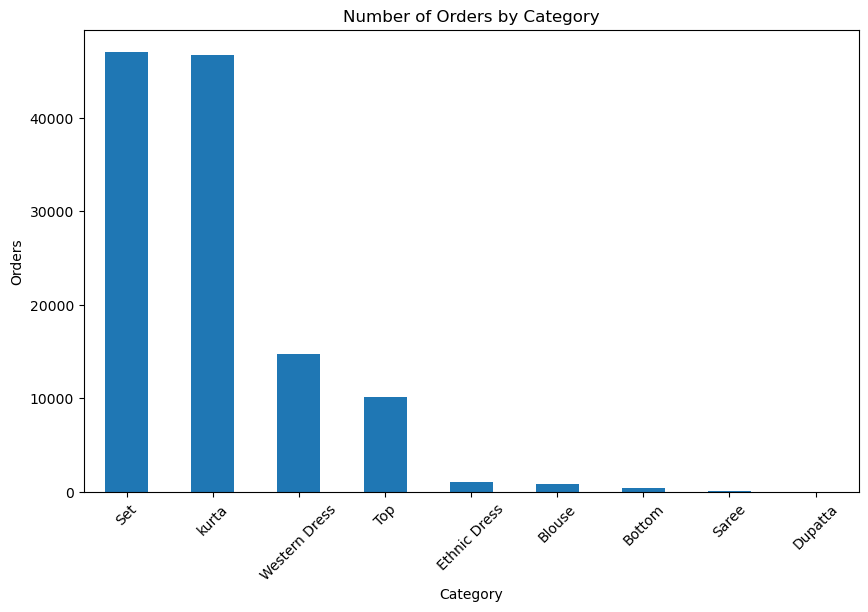

In [10]:
plt.figure(figsize=(10,6))

category_orders.plot(kind="bar")

plt.title("Number of Orders by Category")
plt.xlabel("Category")
plt.ylabel("Orders")
plt.xticks(rotation=45)

plt.show()

Revenue by Category

In [11]:
category_revenue = (
    df.groupby("Category")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

Category
Set              39204124.03
kurta            21299546.70
Western Dress    11216072.69
Top               5347792.30
Ethnic Dress       791217.66
Blouse             458408.18
Bottom             150667.98
Saree              123933.76
Dupatta               915.00
Name: Amount, dtype: float64

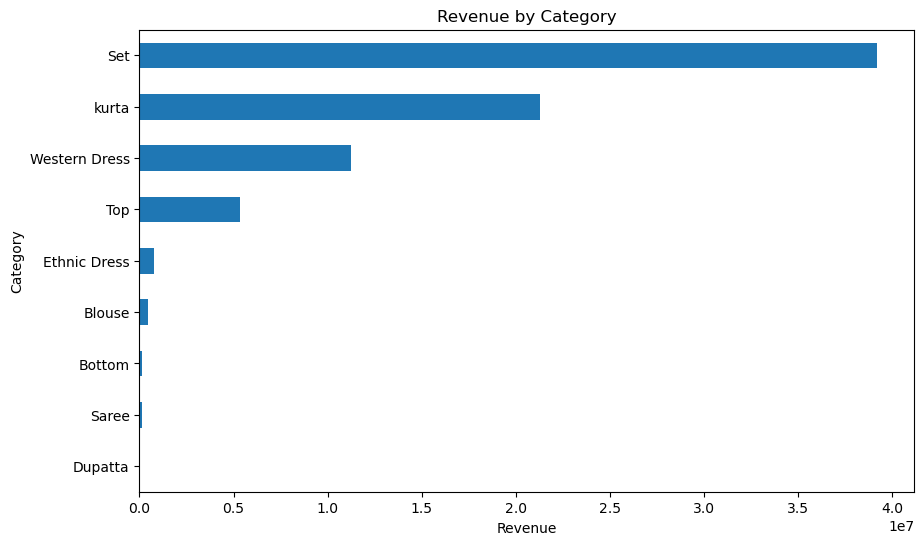

In [21]:
plt.figure(figsize=(10,6))

category_revenue.sort_values().plot(kind="barh")

plt.title("Revenue by Category")

plt.xlabel("Revenue")

plt.show()

Quantity Sold by Category

In [13]:
category_qty = (
    df.groupby("Category")["Qty"]
      .sum()
      .sort_values(ascending=False)
)

category_qty

Category
Set              45225
kurta            44970
Western Dress    13939
Top               9899
Ethnic Dress      1053
Blouse             844
Bottom             397
Saree              152
Dupatta              3
Name: Qty, dtype: int64

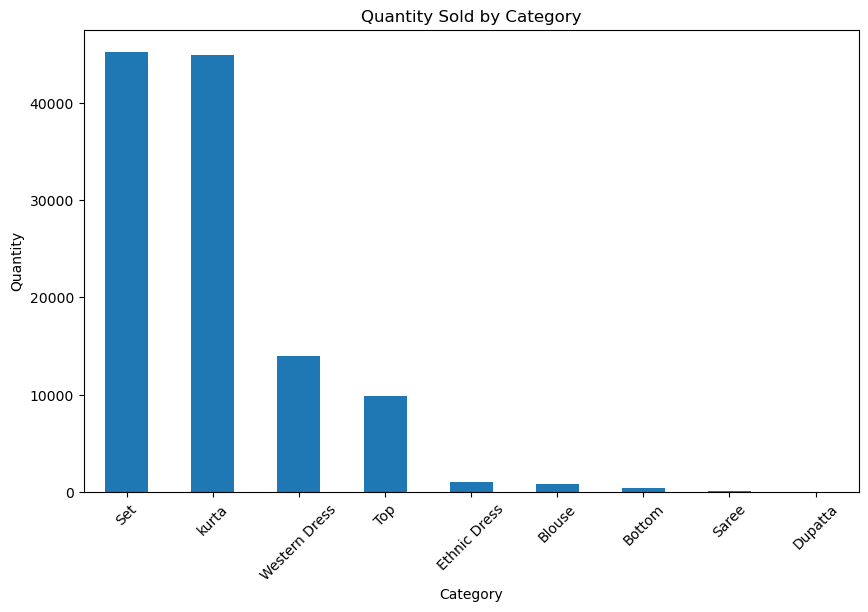

In [14]:
plt.figure(figsize=(10,6))

category_qty.plot(kind="bar")

plt.title("Quantity Sold by Category")

plt.ylabel("Quantity")

plt.xticks(rotation=45)

plt.show()

Top 10 SKUs

In [15]:
top_sku = (
    df.groupby("SKU")["Qty"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_sku

SKU
JNE3797-KR-L       661
JNE3797-KR-M       561
JNE3797-KR-S       503
JNE3405-KR-L       480
J0230-SKD-M        468
J0230-SKD-S        421
JNE3797-KR-XL      415
JNE3405-KR-S       399
JNE3797-KR-XS      386
SET268-KR-NP-XL    371
Name: Qty, dtype: int64

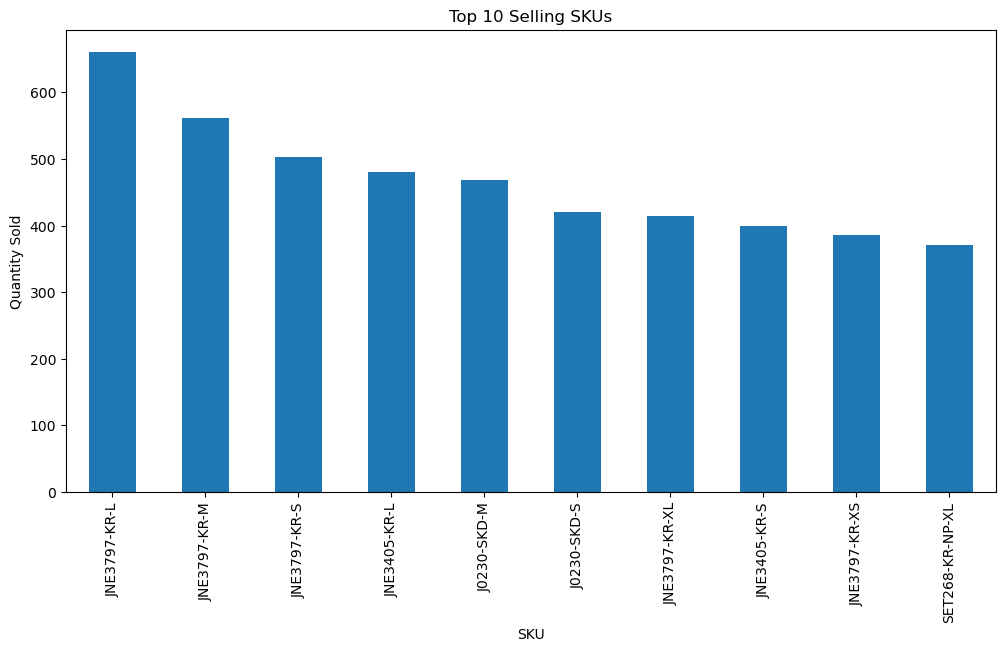

In [16]:
plt.figure(figsize=(12,6))

top_sku.plot(kind="bar")

plt.title("Top 10 Selling SKUs")

plt.ylabel("Quantity Sold")

plt.xticks(rotation=90)

plt.show()

Top Styles

In [17]:
top_style = (
    df.groupby("Style")
      .size()
      .sort_values(ascending=False)
      .head(10)
)

top_style

Style
JNE3797    3995
JNE3405    2104
J0230      1733
SET268     1732
J0341      1538
J0003      1491
SET324     1206
SET345     1152
JNE3373    1078
JNE3440     993
dtype: int64

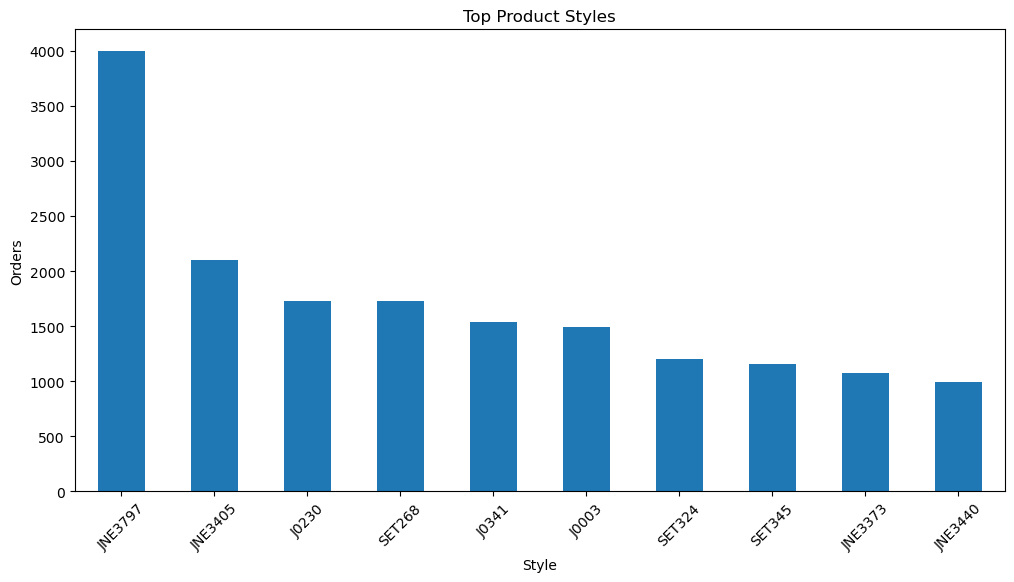

In [18]:
plt.figure(figsize=(12,6))

top_style.plot(kind="bar")

plt.title("Top Product Styles")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

Product Size Distribution

In [19]:
size_orders = (
    df["Size"]
      .value_counts()
)

size_orders

Size
M       21292
L       20800
XL      19726
XXL     17066
S       15953
3XL     14052
XS      10296
6XL       705
5XL       526
4XL       408
Free      356
Name: count, dtype: int64

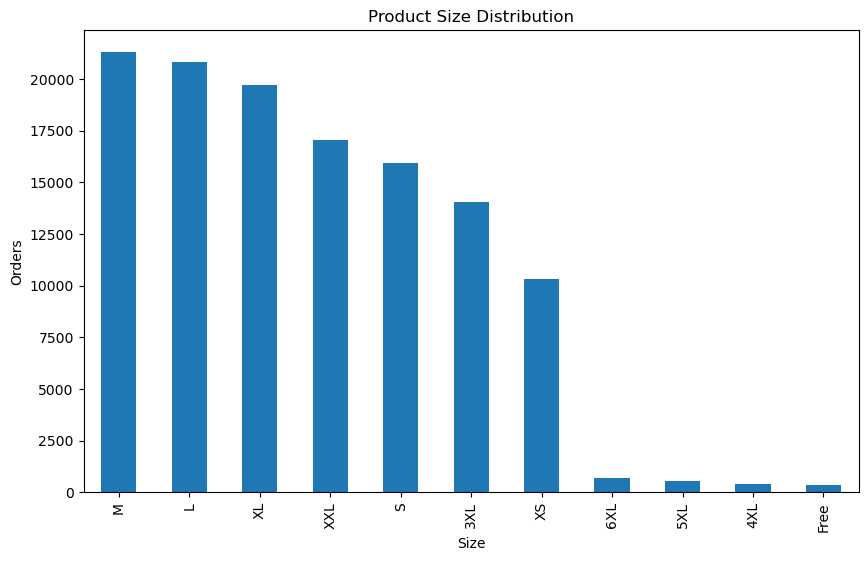

In [20]:
plt.figure(figsize=(10,6))

size_orders.plot(kind="bar")

plt.title("Product Size Distribution")

plt.xlabel("Size")

plt.ylabel("Orders")

plt.show()

Product Analysis - Business Insight

Product performance is heavily concentrated in the Set and Kurta categories, which together generate the majority of orders, quantities sold, and revenue. The JNE3797 style and its associated SKUs consistently rank among the best-selling products, demonstrating strong customer preference. Additionally, Medium, Large, and XL sizes dominate sales, highlighting clear demand patterns that can support inventory optimization, procurement planning, and targeted marketing strategies.

- Set and Kurta categories dominate sales, contributing over 70% of total orders.
- Sets generate the highest revenue, making them the most profitable category.
- M, L, and XL are the most demanded sizes, indicating customer preference toward standard sizing.
- JNE3797 is the highest-performing style, with several of its SKUs appearing among the top-selling products.